MOST DEMANDED SKILLS FOR THE TOP 3 MOST POPULAR DATA ROLES

In [2]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import seaborn as sns


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Phython\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_Skill_Explode = df.explode('job_skills')
Most_Demanded_Skills = df_Skill_Explode.groupby(['job_skills', 'job_title_short']).size()
Most_Demanded_Skills = Most_Demanded_Skills.reset_index(name= 'Skill_Count')
Most_Demanded_Skills.sort_values(by='Skill_Count', ascending=False, inplace=True)
Most_Demanded_Skills



,job_skills,job_title_short,Skill_Count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [4]:
Most_Popular_Data_Role = list(
    df_Skill_Explode['job_title_short']
    .value_counts()
    .head(3)
    .index
)
Most_Popular_Data_Role

['Data Engineer', 'Data Scientist', 'Data Analyst']

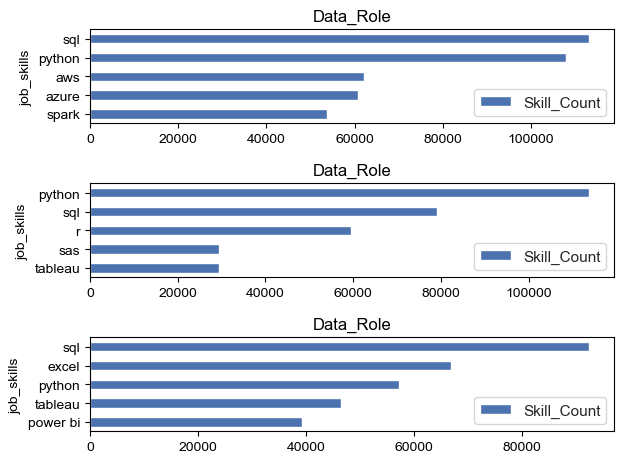

In [5]:
fig, ax = plt.subplots(3, 1)
sns.set_theme(style='ticks')


for i, Data_Role in enumerate(Most_Popular_Data_Role):
    df_Plot = Most_Demanded_Skills[Most_Demanded_Skills['job_title_short'] == Data_Role].head(5)
    #sns.barplot(data= Most_Demanded_Skills, x='job_skills', y='Skill_Count', ax=ax[i], hue='Skill_Count', palette='light:b', legend=False)
    df_Plot.plot(kind='barh', x='job_skills', y='Skill_Count', ax=ax[i])
    ax[i].invert_yaxis()
    ax[i].set_title('Data_Role')

      

     




fig.tight_layout()





C:\Users\USER\AppData\Local\Temp\ipykernel_5264\219882555.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_5264\219882555.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_5264\219882555.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


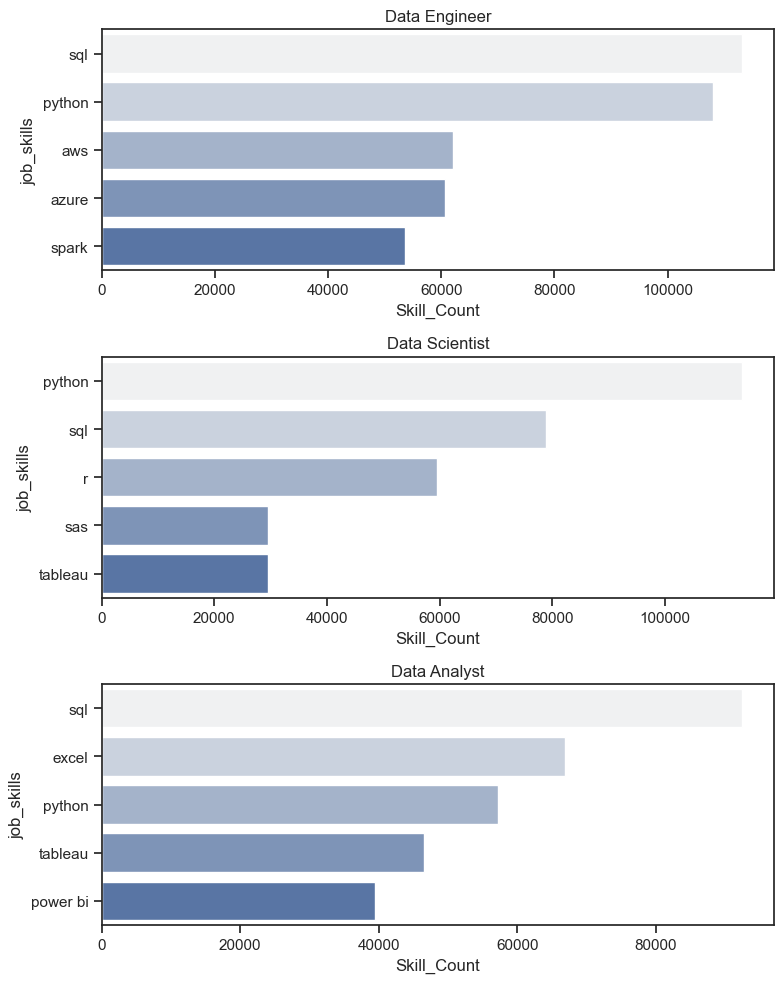

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10))
sns.set_theme(style='ticks')

for i, Data_Role in enumerate(Most_Popular_Data_Role):
    
    df_Plot = Most_Demanded_Skills[
        Most_Demanded_Skills['job_title_short'] == Data_Role
    ].head(5)

    sns.barplot(
        data=df_Plot,
        x='Skill_Count',
        y='job_skills',
        ax=ax[i],
        palette='light:b'
    )

    ax[i].set_title(Data_Role)

plt.tight_layout()
plt.show()


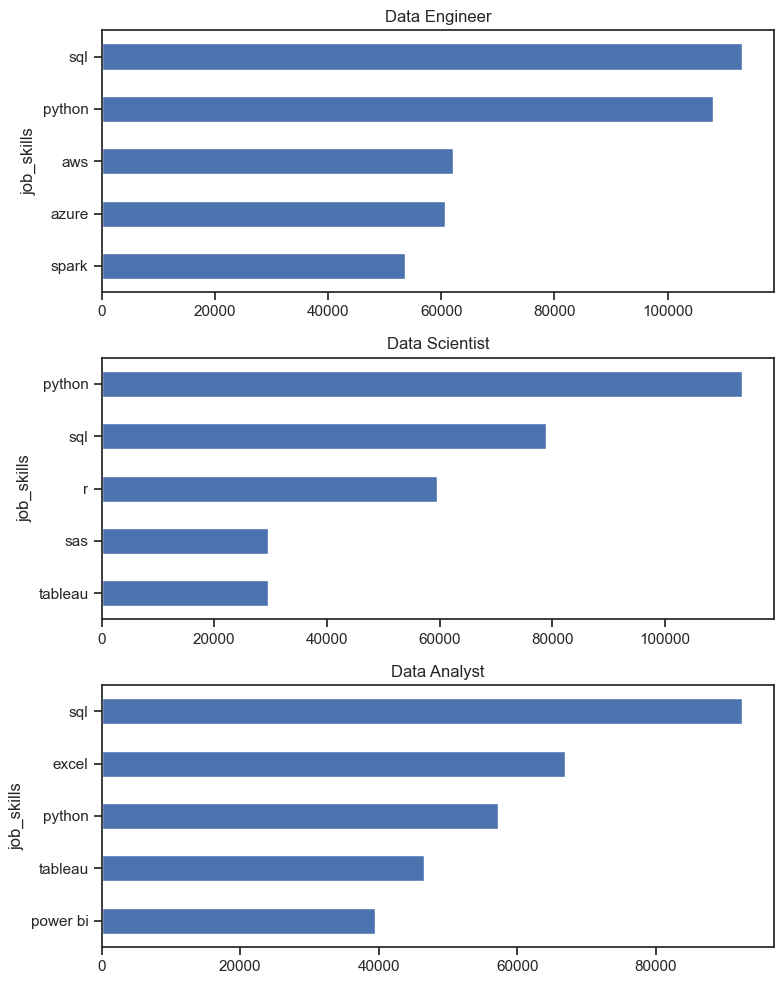

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

for i, job_role in enumerate(Most_Popular_Data_Role):
    df_plot = Most_Demanded_Skills[
        Most_Demanded_Skills['job_title_short'] == job_role
    ].head(5)
    
    df_plot.plot(
        kind='barh',
        x='job_skills',
        y='Skill_Count',
        ax=ax[i],
        legend=False
    )
    
    ax[i].set_title(job_role)
    ax[i].invert_yaxis()

plt.tight_layout()
plt.show()

In [8]:
df_Skill_Explode['job_title_short'].value_counts()

job_title_short
Data Engineer                1150840
Data Scientist                826199
Data Analyst                  672513
Senior Data Engineer          317366
Software Engineer             226375
Senior Data Scientist         188844
Business Analyst              145140
Senior Data Analyst           121263
Machine Learning Engineer      78919
Cloud Engineer                 49861
Name: count, dtype: int64

NUMBER OF JOBS PER JOB TITLE


<Axes: xlabel='count', ylabel='job_title'>

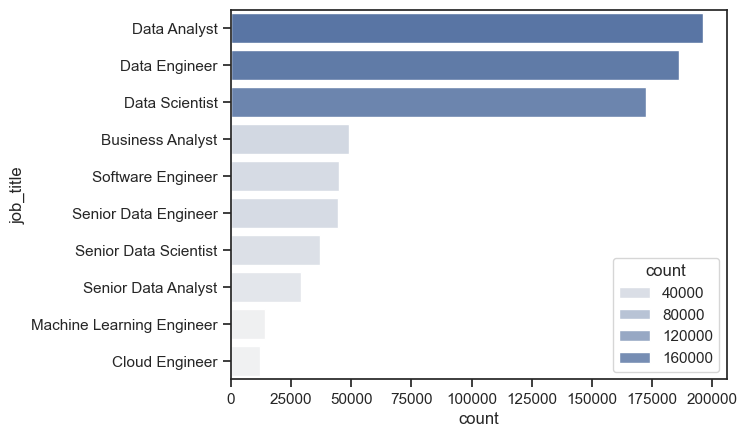

In [9]:
job_counts = df['job_title_short'].value_counts().reset_index(name='job_role_counts')
job_counts.columns = ['job_title', 'count']

sns.barplot(data=job_counts, x='count', y='job_title', hue='count', palette='light:b')

<Axes: xlabel='count', ylabel='job_Country'>

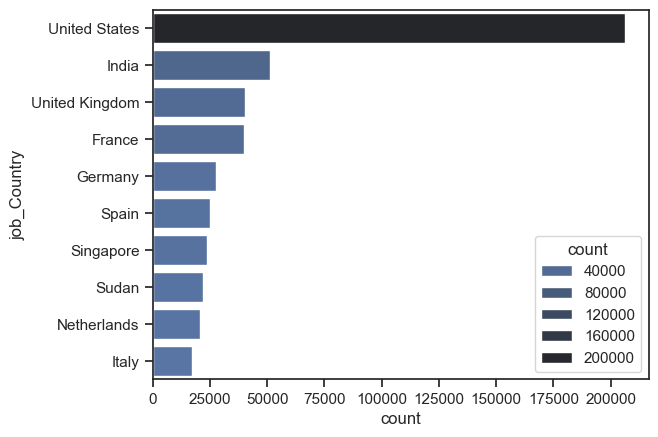

In [21]:
Job_Per_Country = df['job_country'].value_counts().reset_index().head(10)
Job_Per_Country.columns = ['job_Country', 'count']
sns.barplot(data=Job_Per_Country, x='count', y='job_Country', hue='count', palette='dark:b_r')

Text(0.5, 1.0, 'Job Role Per Company')

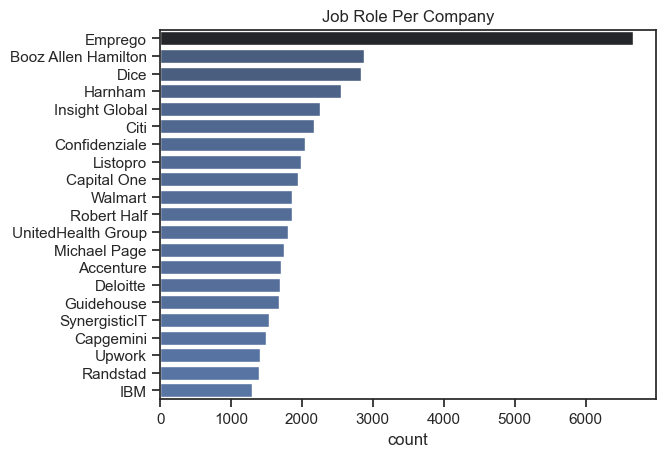

In [39]:
Number_of_jobs_country = df['company_name'].value_counts().reset_index().head(21)
Number_of_jobs_country.columns = ['company_name', 'count']
sns.barplot(data=Number_of_jobs_country, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
plt.ylabel('')
plt.title('Job Role Per Company')